## CSCI-4041 - Algorithms - Chapter 6

## Heaps

### Joy Upton Azzam

### 2/14/2026

<mark>_____________________________________________________________________________________</mark>

### 1. Load the Array Based Tree

The ```%run FILE_NAME``` command is a Jupyter magic command which is sent to the Jupyter server and is not part of Python. It can however be used to load other Jupyter notebooks so that you do not have to copy paste the code. The affect of this command is as if you had copy pasted the code here, so whatever code is in the other notebook file, will be loaded for this notebook file. Note, this can be done in a chain to load many different Jupyter Notebook files and codes.

*example*
The output from running the code below will print the output of the other file, which is the simple example tree.

In [4]:
%%capture
%run Ch6_ArrayTree.ipynb

<mark>_____________________________________________________________________________________</mark>

### 2. Heap Data Structure

The heap is an array-based tree with additional operations. We can define such a tree re-using our ```arraytree``` code from the file loaded above.

In [ ]:
class heap(arraytree):
    """a heap class which is a child of the arraytree class  based on chapter 6 of CLRS"""

    def __init__(self,n,A=None):
        """constructor for heaps with capacity n"""
        super().__init__(n,A)        # if data is passed here, arraytree will not copy it (in-place).
        #           # when no data A is passed above, arraytree generates an empty array of size n
        if A:                        # if data array is passed to constructor
            self.build_max_heap()    # heapify the data in-place
    
    def sort(self):
        """heap-sort algorithm from CLRS-chapter 6"""
        n = self.size # save original size
        
        for i in range(self.size-1,0,-1):
            self.A[0],self.A[i] = self.A[i],self.A[0]
            self.size = self.size - 1
            self.max_heapify(0)

        self.size = n # restore original size (for printing)
    
    def build_max_heap(self):
        """constructs the heap for array A of size n from CLRS-chapter 6"""
        for i in range(self.size//2,-1,-1):
            self.max_heapify(i)
    
    def max_heapify(self,i):
        """max-heapify algorithm from CLRS-chapter 6"""
        
        l = self.left(i)     # left child index
        r = self.right(i)    # right child index
        
        if l < self.size and self.A[l] > self.A[i]: # check for larger child
            largest = l
        else:
            largest = i
        
        if r < self.size and self.A[r] > self.A[largest]:
            largest = r
    
        if largest != i:
            self.A[i],self.A[largest] = self.A[largest],self.A[i]
            self.max_heapify(largest)

    def __str__(self):
        """returns a string for text printing purposes"""
        return str(self.A)

<mark>_____________________________________________________________________________________</mark>

### 3. Testing the Heap

[3, 9, 4, 8, 1, 2, 6, 5, 10, 0]


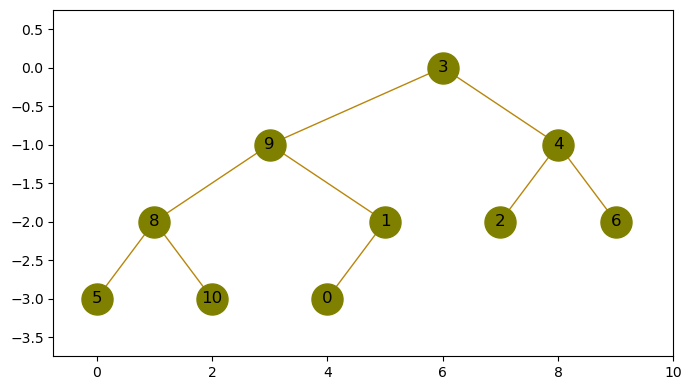

In [10]:
A = [3,9,4,8,1,2,6,5,10,0]
n = len(A)
print(A)
T0 = arraytree(n,A)
PrintTreeArray(T0)

[10, 9, 6, 8, 1, 2, 4, 5, 3, 0]


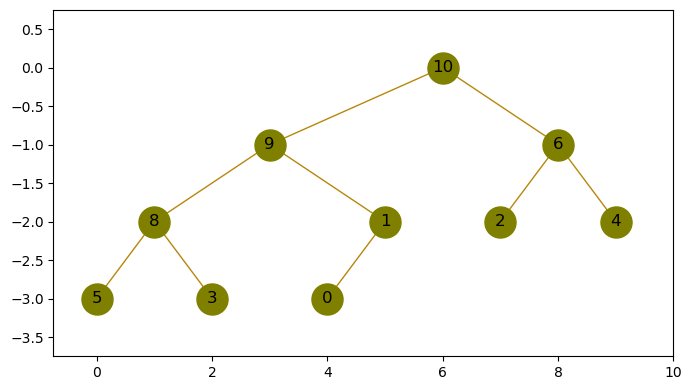

In [11]:
H = heap(n,A)
print(H)
PrintTreeArray(H)

[0, 1, 2, 3, 4, 5, 6, 8, 9, 10]


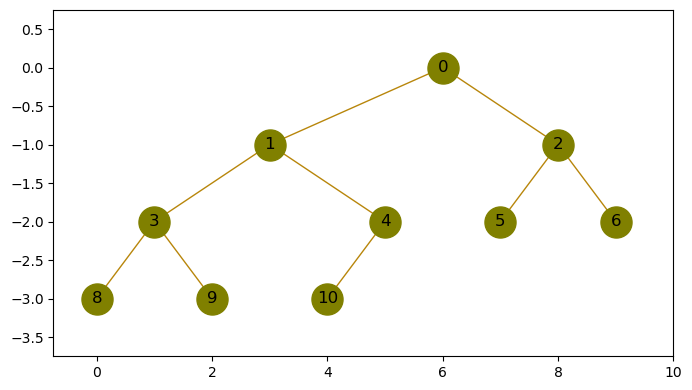

In [12]:
H.sort()
print(H)
PrintTreeArray(H)